In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
%matplotlib inline

import os 
os.chdir('..')

# load some helper functions to read the data
from ingest import ingest_data, alert_lc, plot_alert_lc, unpack_lc_features

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data ingestion

In [8]:
# path to your data
data_path = "/Users/atzanida/Downloads/rubindata"

# Ingest data from one night using medium alert package from Fink
data = ingest_data(data_path, columns=['diaObject', 'prvDiaSources', 
                                       'prvDiaForcedSources', 'lc_features',
                                         'xm', 'timestamp'], latest_only=True)

100%|██████████| 3647/3647 [02:02<00:00, 29.89it/s]


## Append Variability Flag to main DataFrame

In [10]:
data['gaia_var_flag'] = np.array([vf['gaiadr3_VarFlag'] for vf in tqdm(data['xm'])]) 

100%|██████████| 12064/12064 [00:00<00:00, 315950.37it/s]


In [ ]:
data.head(3)

,diaObject,prvDiaSources,prvDiaForcedSources,lc_features,xm,timestamp,diaObjectId,MJD_stamp,gaia_var_flag
0,"{'dec': -49.21768100827329, 'decErr': 2.826469...","[{'apFlux': 77.98568725585938, 'apFluxErr': 27...","[{'band': 'r', 'dec': -49.2176736824231, 'dete...","{'g': {'amplitude': 1115.184326171875, 'anders...",{'gaiadr3_DR3Name': 'Gaia DR3 4829997694255482...,2026-02-26 02:47:49.261658,313761042264490001,61097.116542,0
1,"{'dec': -50.308708661919944, 'decErr': 2.73674...","[{'apFlux': 222.41055297851562, 'apFluxErr': 2...","[{'band': 'i', 'dec': -50.30871180363397, 'det...","{'g': {'amplitude': 985.6874694824219, 'anders...",{'gaiadr3_DR3Name': 'Gaia DR3 4829649630105643...,2026-02-26 02:47:49.261658,313761042224644106,61097.116542,0
2,"{'dec': -50.58974810564185, 'decErr': 5.480157...","[{'apFlux': 705.756591796875, 'apFluxErr': 550...","[{'band': 'i', 'dec': -50.589745168096165, 'de...","{'g': None, 'i': {'amplitude': 2231.6922912597...",{'gaiadr3_DR3Name': 'Gaia DR3 4829625857462394...,2026-02-26 02:47:49.261658,170028486049136765,61097.116542,0


In [15]:
print (f"Total number of (Gaia good) alerts on night: {len(data)}")
print (f"Total number of (Gaia good) alerts on night with VARFLAG=0: {len(data['gaia_var_flag'][data['gaia_var_flag']==0])}")
print (f"Total number of (Gaia good) alerts on night with VARFLAG=1: {len(data['gaia_var_flag'][data['gaia_var_flag']==1])}")
print (f"Ratio VARFLAG=1/VARFLAG=0: {len(data['gaia_var_flag'][data['gaia_var_flag']==1]) / len(data['gaia_var_flag'][data['gaia_var_flag']==0])}")

Total number of (Gaia good) alerts on night: 12064
Total number of (Gaia good) alerts on night with VARFLAG=0: 12006
Total number of (Gaia good) alerts on night with VARFLAG=1: 58
Ratio VARFLAG=1/VARFLAG=0: 0.004830917874396135


In [ ]:
def avg_reliability_byband(data_table, band='r'):
    """Return the average reliability by band.
    
    Parameters:
    -----------
    data_table : pandas.DataFrame
        The input data table containing light curve information.
    band : str
        The photometric band to compute the average reliability for.

    Returns: 
    --------
    average reliability for the specified band for non-variables (0) and variables (1).
    """
    avg_reliability = []
    for _id in tqdm(data_table['diaObjectId']):
        lc = alert_lc(data_table, _id, 
                alert_lc_type='prvDiaSources',
                    flux_ref='scienceFlux', # PSF on the science visit image center at DiaSource
                    band=band)
        avg_reliability.append(lc['reliability'].mean())

    avg_reliability = np.array(avg_reliability)
    rmv_bogus = ~np.isnan(avg_reliability)
    avg_reliability = avg_reliability[rmv_bogus]
    reliable_data = data_table[rmv_bogus]

    return avg_reliability[reliable_data['gaia_var_flag']==0], avg_reliability[reliable_data['gaia_var_flag']==1]

In [17]:
rel_g = avg_reliability_byband(data, band='g')
rel_r = avg_reliability_byband(data, band='r')
rel_i = avg_reliability_byband(data, band='i')
rel_z = avg_reliability_byband(data, band='z')
rel_y = avg_reliability_byband(data, band='y')

100%|██████████| 12064/12064 [00:55<00:00, 218.06it/s]


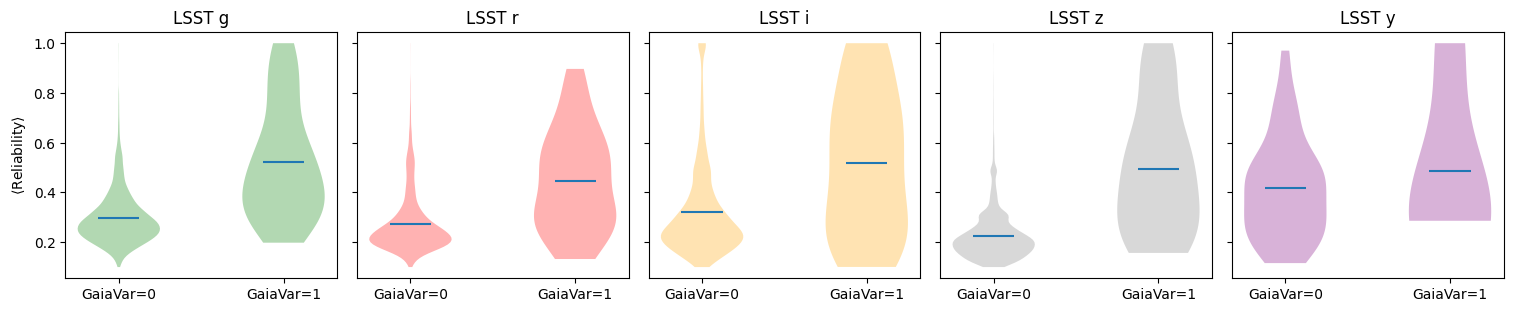

In [18]:
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(15,3), sharey=True)

part_g = ax[0].violinplot(
    [rel_g[0], rel_g[1]],
    positions=[0, 1],
    showmeans=True,
    showmedians=False,
    showextrema=False)
# set part_g color to green
for pc in part_g['bodies']:
    pc.set_facecolor('green')

part_r = ax[1].violinplot(
    [rel_r[0], rel_r[1]],
    positions=[0, 1],
    showmeans=True,
    showmedians=False,
    showextrema=False)
# set part_r color to red
for pc in part_r['bodies']:
    pc.set_facecolor('red')

part_i = ax[2].violinplot(
    [rel_i[0], rel_i[1]],
    positions=[0, 1],
    showmeans=True,
    showmedians=False,
    showextrema=False)
# set part_i color to orange
for pc in part_i['bodies']:
    pc.set_facecolor('orange')

part_z = ax[3].violinplot(
    [rel_z[0], rel_z[1]],
    positions=[0, 1],
    showmeans=True,
    showmedians=False,
    showextrema=False)
# set part_z color to blue
for pc in part_z['bodies']:
    pc.set_facecolor('gray')

part_y = ax[4].violinplot(
    [rel_y[0], rel_y[1]],
    positions=[0, 1],
    showmeans=True,
    showmedians=False,
    showextrema=False)
# set part_y color to magenta
for pc in part_y['bodies']:
    pc.set_facecolor('purple')

plt.tight_layout()

for i in range(5):
    ax[i].set_xticks([0, 1])
    ax[i].set_xticklabels(['GaiaVar=0', 'GaiaVar=1'])

ax[0].set_ylabel(r'$\langle \mathrm{Reliability} \rangle$')
for i, color in zip(range(5), list('grizy')):
    ax[i].set_title(f"LSST {color}")